# Business Understanding

## Contexto do Negócio

A **Solução Casting** é uma empresa de gestão de desempenho de vendas, fornecendo indicadores estratégicos para acompanhamento da performance de vendedores, lojas e clientes.

Atualmente, a empresa utiliza dados históricos para análise de desempenho, porém **não possui um modelo robusto de previsão de faturamento**. As estimativas existentes são baseadas em abordagens simplificadas e estáticas, sem considerar padrões temporais, sazonalidade ou variações no comportamento de vendas.

---

## Problema de Negócio

O processo atual de previsão apresenta limitações importantes:

- Baixa assertividade nas previsões
- Falta de adaptação às mudanças no comportamento de vendas
- Ausência de modelagem de tendência e sazonalidade
- Processo manual e pouco escalável
- Dificuldade em apoiar decisões estratégicas com antecedência

---

## Objetivo do Projeto

Desenvolver um modelo de Machine Learning capaz de **prever o faturamento futuro** com base em dados históricos de vendas.

**Variável-alvo:** `VUF_VLRLIQFINAL` — valor líquido final da venda (já com descontos e devoluções)

**Abordagem:** Previsão de séries temporais em granularidade **mensal**, horizonte de **3 a 6 meses**.

---

## Dicionário de Dados

| Coluna | Tipo | Descrição |
|---|---|---|
| `VUF_CODIGO` | UUID | Identificador único da transação |
| `VUF_CODIGO_BOLETO` | String | Código do boleto vinculado à venda |
| `UND_CODIGO` | UUID | Código da unidade (loja/filial) |
| `FUN_CODIGO` | UUID | Código do funcionário (vendedor) |
| `VUF_DT` | Date | Data da transação |
| `PRO_CODIGO` | UUID | Código do produto vendido |
| `CAT_CODIGO` | UUID | Código da categoria do produto |
| `VUF_QTBOLETO` | Int (0/1) | Flag: 1 = venda com boleto, 0 = sem boleto |
| `VUF_QTPRODUTO` | Float | Quantidade de produtos na transação (negativo = devolução) |
| `VUF_VLRBRUTOVENDA` | Float | Valor bruto da venda (negativo = devolução) |
| `VUF_VLRDESCONTO` | Float | Valor do desconto aplicado (negativo = desconto estornado em devolução) |
| `VUF_VLRLIQFINAL` | Float | **Valor líquido final** — variável-alvo do modelo |
| `VUF_VLRTROCA` | Float | Valor de troca |
| `CLV_BANCO` | String | Identificador da loja/base de dados de origem |

---
# 1. Setup e Ingestão de Dados

In [1]:
import glob
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

In [2]:
path = '../data/raw/CASTING_*.csv'
path_csv = glob.glob(path)
print(f'Arquivos encontrados: {len(path_csv)}')
for p in sorted(path_csv):
    print(f'  {p}')

Arquivos encontrados: 8
  ../data/raw\CASTING_DB063.csv
  ../data/raw\CASTING_DB069.csv
  ../data/raw\CASTING_DB088.csv
  ../data/raw\CASTING_DB092.csv
  ../data/raw\CASTING_DB101.csv
  ../data/raw\CASTING_DB102.csv
  ../data/raw\CASTING_DB109.csv
  ../data/raw\CASTING_DB113.csv


In [3]:
dfs = [pd.read_csv(i, low_memory=False) for i in path_csv]
df = pd.concat(dfs, ignore_index=True)

print(f'Total de Linhas : {df.shape[0]:,}')
print(f'Total de Colunas: {df.shape[1]}')
display(df.head())

Total de Linhas : 8,297,456
Total de Colunas: 14


,VUF_CODIGO,VUF_CODIGO_BOLETO,UND_CODIGO,FUN_CODIGO,VUF_DT,PRO_CODIGO,CAT_CODIGO,VUF_QTBOLETO,VUF_QTPRODUTO,VUF_VLRBRUTOVENDA,VUF_VLRDESCONTO,VUF_VLRLIQFINAL,VUF_VLRTROCA,CLV_BANCO
0,24A7937E-49F8-4ED1-B610-BB7995DC4106,1000000,B942EA32-EAFF-40ED-A728-0FE9C765F812,9BB64E05-6462-4CD6-8F2C-D2ADC9DA8765,2022-05-22,3E5B7FB9-4844-44A6-B385-241017D41A28,C179DA0E-8301-4088-8373-E26B6FEE99C3,1,1.00,189.99,0.00,189.99,0.00,CASTING_DB063
1,8010F727-5671-48B5-8C23-E952CD191984,1000001,31893136-A4A0-4472-BBB4-2EC814E5D86E,03CC7BB1-5F67-4569-AE52-3D359772B2F7,2022-05-22,EB4285C5-A15D-4950-AB33-574F4A18F529,C179DA0E-8301-4088-8373-E26B6FEE99C3,0,1.00,119.99,0.00,119.99,0.00,CASTING_DB063
2,0117A275-8992-4C64-A071-9D0B5C95A1A9,1000001,31893136-A4A0-4472-BBB4-2EC814E5D86E,03CC7BB1-5F67-4569-AE52-3D359772B2F7,2022-05-22,A986B967-2D6A-4CE0-82AA-EAEF42685001,B857F5D2-727A-4535-8DFA-8D3E2643117D,1,1.00,99.99,0.00,99.99,0.00,CASTING_DB063
3,42D434F5-64D2-4E4B-AF4A-F5C9FCC36630,1000002,AAFEB5A5-28F4-4E9C-9AD4-6932C4533F59,523BCE27-EDD6-40A6-8E4D-08C765F0C776,2022-05-22,49022E30-FF7A-4B4C-BD15-9DC816B6A1A0,D8BB8C86-1982-4D71-A085-80A75C213765,1,1.00,199.99,0.00,199.99,0.00,CASTING_DB063
4,C0455B0D-06C2-4F96-AFB2-BB44C19812EA,1000003,37FB9E33-B405-4727-9495-7E4F2D356298,EB9E6583-0CEC-4B69-8ABF-AD96AE086987,2022-05-22,95780F7C-7299-47E8-BB42-06435BD173BB,B857F5D2-727A-4535-8DFA-8D3E2643117D,1,1.00,249.99,0.00,249.99,0.00,CASTING_DB063


---
# 2. Inspeção Inicial da Estrutura

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8297456 entries, 0 to 8297455
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   VUF_CODIGO         object 
 1   VUF_CODIGO_BOLETO  object 
 2   UND_CODIGO         object 
 3   FUN_CODIGO         object 
 4   VUF_DT             object 
 5   PRO_CODIGO         object 
 6   CAT_CODIGO         object 
 7   VUF_QTBOLETO       int64  
 8   VUF_QTPRODUTO      float64
 9   VUF_VLRBRUTOVENDA  float64
 10  VUF_VLRDESCONTO    float64
 11  VUF_VLRLIQFINAL    float64
 12  VUF_VLRTROCA       float64
 13  CLV_BANCO          object 
dtypes: float64(5), int64(1), object(8)
memory usage: 886.3+ MB


In [5]:
# Corrigindo tipos antes de qualquer análise
df['VUF_DT'] = pd.to_datetime(df['VUF_DT'], errors='coerce')

print('Período coberto pelos dados:')
print(f'  Início : {df["VUF_DT"].min().date()}')
print(f'  Fim    : {df["VUF_DT"].max().date()}')
print(f'  Meses  : {df["VUF_DT"].dt.to_period("M").nunique()}')

Período coberto pelos dados:
  Início : 2022-01-01
  Fim    : 2023-10-01
  Meses  : 22


In [6]:
print('Lojas presentes no dataset:')
display(df['CLV_BANCO'].value_counts().rename_axis('Loja').reset_index(name='Transações'))

Lojas presentes no dataset:


,Loja,Transações
0,CASTING_DB063,2854643
1,CASTING_DB113,2384600
2,CASTING_DB109,1393118
3,CASTING_DB092,789118
4,CASTING_DB102,283816
5,CASTING_DB088,274956
6,CASTING_DB101,223574
7,CASTING_DB069,93631


---
# 3. Análise de Qualidade dos Dados

## 3.1 Valores Nulos

In [7]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumo_nulos = pd.DataFrame({'Nulos': nulos, '% do Total': nulos_pct})
display(resumo_nulos[resumo_nulos['Nulos'] > 0])

,Nulos,% do Total
VUF_CODIGO_BOLETO,12125,0.15
PRO_CODIGO,3,0.00


**Análise:** Apenas `VUF_CODIGO_BOLETO` e `PRO_CODIGO` possuem nulos. Ambos representam ausência de mapeamento cadastral, não transações inválidas. `PRO_CODIGO` será preenchido com valor neutro na etapa de tratamento. `VUF_CODIGO_BOLETO` não é utilizado na modelagem e não requer ação.

## 3.2 Duplicatas

In [8]:
duplicatas = df.duplicated(subset=['VUF_CODIGO']).sum()
print(f'Transações duplicadas por VUF_CODIGO: {duplicatas}')

Transações duplicadas por VUF_CODIGO: 0


## 3.3 Estatísticas Descritivas

In [9]:
cols_num = ['VUF_QTPRODUTO', 'VUF_VLRBRUTOVENDA', 'VUF_VLRDESCONTO', 'VUF_VLRLIQFINAL']
display(df[cols_num].describe())

,VUF_QTPRODUTO,VUF_VLRBRUTOVENDA,VUF_VLRDESCONTO,VUF_VLRLIQFINAL
count,"8,297,456.00","8,297,456.00","8,297,456.00","8,297,456.00"
mean,0.89,285.84,47.62,228.44
std,0.79,503.08,272.46,360.11
min,-600.00,"-43,020.00","-18,612.91","-43,020.00"
25%,1.00,79.99,0.00,69.99
50%,1.00,199.99,0.00,178.28
75%,1.00,389.00,5.00,299.99
max,600.00,"72,800.00","27,090.90","72,800.00"


**Observações importantes:**
- `VUF_QTPRODUTO`, `VUF_VLRBRUTOVENDA` e `VUF_VLRLIQFINAL` possuem valores **negativos** — são **devoluções legítimas**. O sistema espelha a transação original com todos os valores invertidos (bruto, desconto e líquido).
- `VUF_QTBOLETO` é uma **flag binária** (0 = sem boleto, 1 = com boleto).
- O `max` de `VUF_VLRLIQFINAL` (R$ 72.800) indica vendas de altíssimo valor unitário — potenciais outliers de atacado que merecem investigação.

## 3.4 Consistência Financeira: Bruto − Desconto = Líquido

In [10]:
df['_CALC_LIQ'] = df['VUF_VLRBRUTOVENDA'] - df['VUF_VLRDESCONTO']
df['_DIFF']     = (df['VUF_VLRLIQFINAL'] - df['_CALC_LIQ']).abs()

# Guardar o número real para uso no resumo final (evita valor hardcoded)
n_inconsist = int((df['_DIFF'] > 0.01).sum())
pct_inconsist = n_inconsist / len(df) * 100

print(f'Linhas com diferença > R$ 0,01 : {n_inconsist:,} ({pct_inconsist:.1f}% do total)')
print()

# Distribuição por faixa de diferença
print('Distribuição por faixa de diferença:')
bins   = [0.01, 0.05, 0.50, 1.00, 10.00, float('inf')]
labels = ['R$ 0,01–0,05', 'R$ 0,05–0,50', 'R$ 0,50–1,00', 'R$ 1–10', '> R$ 10']
df['_FAIXA'] = pd.cut(df['_DIFF'], bins=bins, labels=labels, right=True)
contagem = df[df['_DIFF'] > 0.01]['_FAIXA'].value_counts().sort_index()
display(contagem.rename('Qtd de linhas').to_frame())

# Impacto financeiro absoluto
impacto_total = df[df['_DIFF'] > 0.01]['_DIFF'].sum()
fat_bruto_total = df[df['VUF_VLRBRUTOVENDA'] > 0]['VUF_VLRBRUTOVENDA'].sum()
print(f'\nImpacto financeiro total das diferenças : R$ {impacto_total:,.2f}')
print(f'Em relação ao faturamento bruto total   : {impacto_total / fat_bruto_total * 100:.4f}%')

# Concentração por loja
print('\nInconsistências por loja (% das transações da loja):')
incon_por_loja  = df[df['_DIFF'] > 0.01].groupby('CLV_BANCO').size()
total_por_loja  = df.groupby('CLV_BANCO').size()
display((incon_por_loja / total_por_loja * 100).round(2).rename('% inconsistente').to_frame())

df.drop(columns=['_CALC_LIQ', '_DIFF', '_FAIXA'], inplace=True)

Linhas com diferença > R$ 0,01 : 984,417 (11.9% do total)

Distribuição por faixa de diferença:


,Qtd de linhas
_FAIXA,
"R$ 0,01–0,05",368
"R$ 0,05–0,50",1542
"R$ 0,50–1,00",1765
R$ 1–10,78870
> R$ 10,901872



Impacto financeiro total das diferenças : R$ 81,734,921.21
Em relação ao faturamento bruto total   : 3.2213%

Inconsistências por loja (% das transações da loja):


,% inconsistente
CLV_BANCO,
CASTING_DB063,0.00
CASTING_DB069,NaN
CASTING_DB088,1.49
CASTING_DB092,2.64
CASTING_DB101,0.00
CASTING_DB102,NaN
CASTING_DB109,1.29
CASTING_DB113,39.48


**Análise das inconsistências financeiras:** A equação `Líquido = Bruto − Desconto` não fecha em parte das linhas. A distribuição por faixa revela se as diferenças são centavos de arredondamento sistêmico ou divergências maiores. Independente da causa, o impacto financeiro absoluto sobre o faturamento total é calculado acima e determina se o efeito é desprezível. Como `VUF_VLRLIQFINAL` é o valor registrado oficialmente pelo sistema PDV e será a variável-alvo do modelo, **ele é mantido como está** — a equação é informativa, não normativa.

## 3.5 Erros Reais de PDV: Desconto maior que Bruto (em transações positivas)

In [11]:
# Erro real: desconto maior que bruto em venda positiva (não é devolução)
mask_pdv = (df['VUF_VLRDESCONTO'] > df['VUF_VLRBRUTOVENDA']) & (df['VUF_VLRBRUTOVENDA'] > 0)
erro_pdv  = df[mask_pdv]

print(f'Erros reais de PDV (desconto > bruto em vendas positivas): {len(erro_pdv)}')
if len(erro_pdv) > 0:
    display(erro_pdv[['CLV_BANCO', 'VUF_DT', 'VUF_VLRBRUTOVENDA', 'VUF_VLRDESCONTO', 'VUF_VLRLIQFINAL']])

# Devoluções legítimas: bruto negativo (comportamento esperado do sistema)
devol = df[df['VUF_VLRBRUTOVENDA'] < 0]
print(f'\nDevoluções legítimas (bruto negativo): {len(devol):,} transações ({len(devol)/len(df)*100:.1f}% do total)')

Erros reais de PDV (desconto > bruto em vendas positivas): 4


,CLV_BANCO,VUF_DT,VUF_VLRBRUTOVENDA,VUF_VLRDESCONTO,VUF_VLRLIQFINAL
1091503,CASTING_DB063,2022-12-31,2.22,2.24,-0.02
1818622,CASTING_DB063,2023-07-27,7.50,7.51,-0.01
4556996,CASTING_DB109,2022-05-23,59.90,"3,534.00",60.00
4682742,CASTING_DB109,2023-09-02,219.90,360.00,219.90



Devoluções legítimas (bruto negativo): 356,273 transações (4.3% do total)


**Conclusão:** Os erros de PDV encontrados (desconto > bruto em transação positiva) serão removidos na etapa de tratamento — representam inconsistência real de cadastro no sistema. Os registros com valores negativos são devoluções legítimas e serão mantidos com flag de identificação.

---
# 4. Análise Exploratória (EDA)

## 4.1 Faturamento Mensal Consolidado

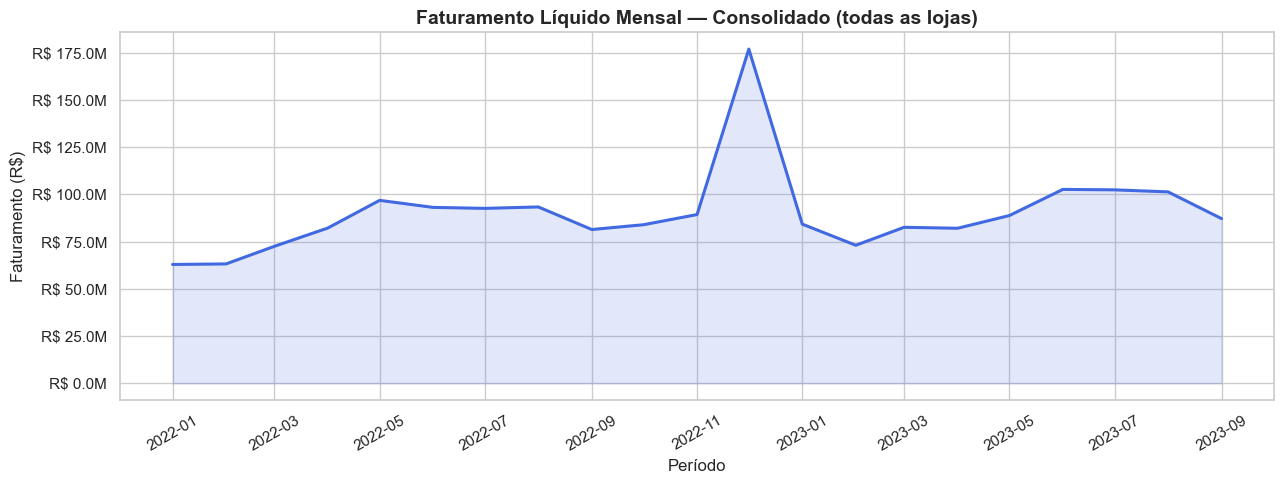

Faturamento médio mensal : R$ 90,168,719
Mês de maior faturamento : Dec/2022 — R$ 176,963,078
Mês de menor faturamento : Jan/2022 — R$ 62,950,047


In [12]:
fmt_brl = mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M')

fat_mensal = (
    df.groupby(df['VUF_DT'].dt.to_period('M'))
    ['VUF_VLRLIQFINAL'].sum()
    .reset_index()
)
fat_mensal['VUF_DT'] = fat_mensal['VUF_DT'].dt.to_timestamp()
fat_mensal = fat_mensal[fat_mensal['VUF_DT'] < '2023-10-01']  # remove mês incompleto

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(fat_mensal['VUF_DT'], fat_mensal['VUF_VLRLIQFINAL'], alpha=0.15, color='royalblue')
sns.lineplot(data=fat_mensal, x='VUF_DT', y='VUF_VLRLIQFINAL', color='royalblue', linewidth=2.2, ax=ax)
ax.yaxis.set_major_formatter(fmt_brl)
ax.set_title('Faturamento Líquido Mensal — Consolidado (todas as lojas)', fontsize=14, fontweight='bold')
ax.set_xlabel('Período')
ax.set_ylabel('Faturamento (R$)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

idx_max = fat_mensal['VUF_VLRLIQFINAL'].idxmax()
idx_min = fat_mensal['VUF_VLRLIQFINAL'].idxmin()
print(f"Faturamento médio mensal : R$ {fat_mensal['VUF_VLRLIQFINAL'].mean():,.0f}")
print(f"Mês de maior faturamento : {fat_mensal.loc[idx_max, 'VUF_DT'].strftime('%b/%Y')} — R$ {fat_mensal.loc[idx_max, 'VUF_VLRLIQFINAL']:,.0f}")
print(f"Mês de menor faturamento : {fat_mensal.loc[idx_min, 'VUF_DT'].strftime('%b/%Y')} — R$ {fat_mensal.loc[idx_min, 'VUF_VLRLIQFINAL']:,.0f}")

## 4.2 Faturamento por Loja

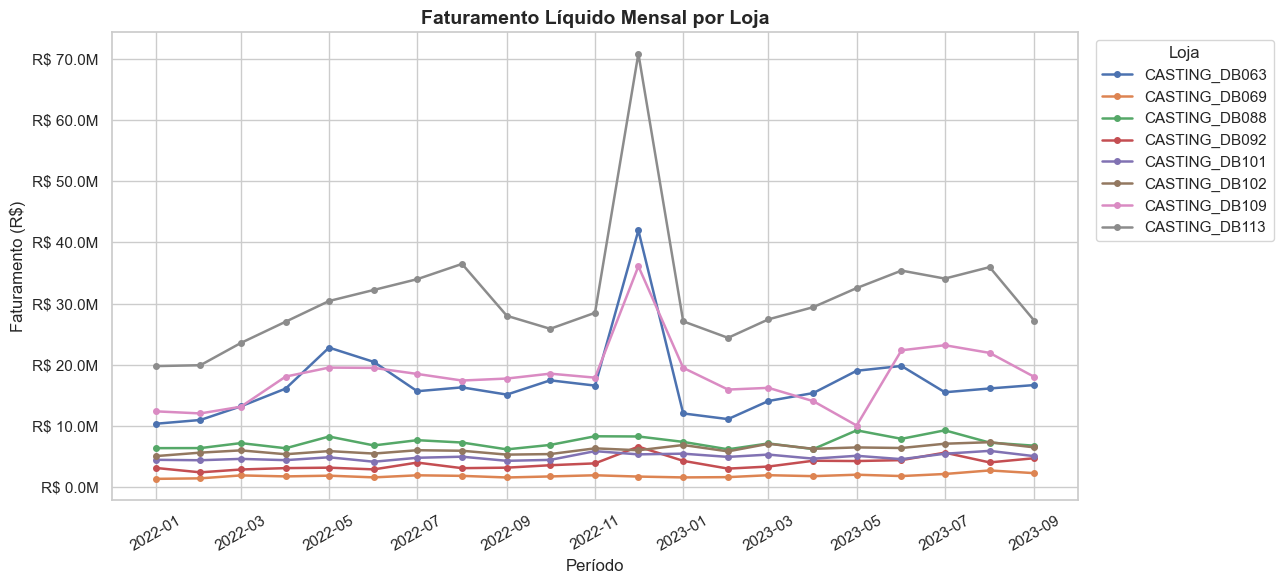

,Transacoes,Fat_Total,Ticket_Medio,Ticket_Mediano,Part_Fat_pct
CLV_BANCO,,,,,
CASTING_DB113,2163418,"738,520,459.80",341.37,279.00,36.10
CASTING_DB109,1301920,"415,071,233.80",318.81,244.99,20.30
CASTING_DB063,2508876,"358,226,137.26",142.78,129.99,17.50
CASTING_DB088,270861,"156,212,032.94",576.72,359.00,7.60
CASTING_DB102,271458,"137,849,191.85",507.81,218.90,6.70
CASTING_DB101,209231,"113,666,587.17",543.26,361.95,5.60
CASTING_DB092,768233,"86,047,552.68",112.01,19.99,4.20
CASTING_DB069,90888,"40,085,557.03",441.04,270.00,2.00


In [13]:
fat_loja_mensal = (
    df[df['VUF_DT'] < '2023-10-01']
    .groupby([df['VUF_DT'].dt.to_period('M'), 'CLV_BANCO'])
    ['VUF_VLRLIQFINAL'].sum()
    .reset_index()
)
fat_loja_mensal['VUF_DT'] = fat_loja_mensal['VUF_DT'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 6))
for loja, grp in fat_loja_mensal.groupby('CLV_BANCO'):
    ax.plot(grp['VUF_DT'], grp['VUF_VLRLIQFINAL'], marker='o', markersize=4, linewidth=1.8, label=loja)

ax.yaxis.set_major_formatter(fmt_brl)
ax.set_title('Faturamento Líquido Mensal por Loja', fontsize=14, fontweight='bold')
ax.set_xlabel('Período')
ax.set_ylabel('Faturamento (R$)')
ax.legend(title='Loja', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Resumo por loja — ordenado por faturamento total
resumo_loja = df[df['VUF_VLRLIQFINAL'] > 0].groupby('CLV_BANCO').agg(
    Transacoes     = ('VUF_CODIGO',      'count'),
    Fat_Total      = ('VUF_VLRLIQFINAL', 'sum'),
    Ticket_Medio   = ('VUF_VLRLIQFINAL', 'mean'),
    Ticket_Mediano = ('VUF_VLRLIQFINAL', 'median')
).round(2)
resumo_loja['Part_Fat_pct'] = (resumo_loja['Fat_Total'] / resumo_loja['Fat_Total'].sum() * 100).round(1)
display(resumo_loja.sort_values('Fat_Total', ascending=False))

**Análise por loja:** O dataset reúne 8 bases com perfis de negócio distintos. As lojas variam amplamente em volume, faturamento e ticket — indicando segmentos de clientes e produtos diferentes. Lojas com ticket mediano muito baixo (~R$ 20) operam em varejo de alto volume; lojas com ticket ~R$ 360 atuam em segmentos de maior valor. Cada loja deverá ser **modelada separadamente** na fase de modelagem.

## 4.3 Análise de Devoluções

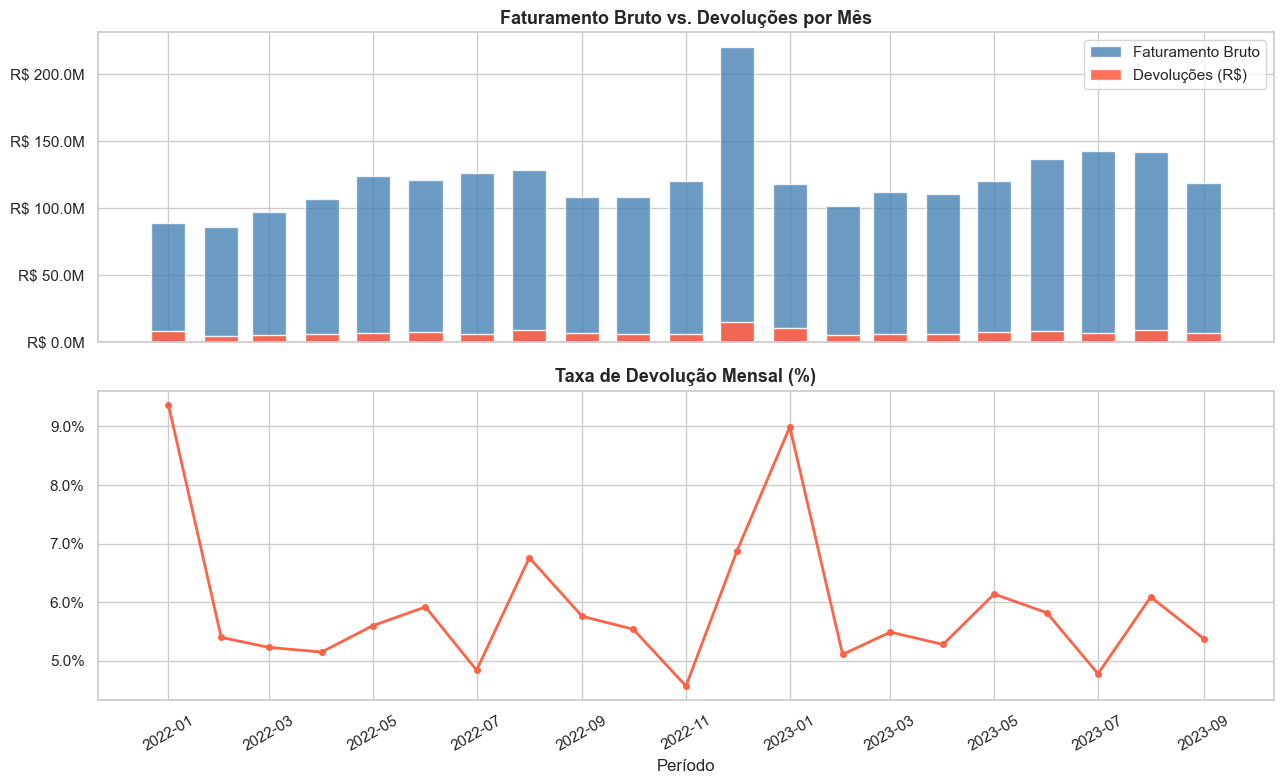

Taxa média de devolução : 5.9%
Taxa máxima de devolução: 9.4% em Jan/2022


In [14]:
devol_mensal = (
    df[df['VUF_DT'] < '2023-10-01']
    .assign(MES=lambda x: x['VUF_DT'].dt.to_period('M'))
    .groupby('MES')
    .agg(
        Fat_Bruto   = ('VUF_VLRBRUTOVENDA', lambda x: x[x > 0].sum()),
        Devol_Valor = ('VUF_VLRLIQFINAL',   lambda x: x[x < 0].sum()),
        Fat_Liquido = ('VUF_VLRLIQFINAL',   'sum')
    )
    .reset_index()
)
devol_mensal['Taxa_Devolucao_pct'] = (devol_mensal['Devol_Valor'].abs() / devol_mensal['Fat_Bruto'] * 100).round(2)
devol_mensal['MES'] = devol_mensal['MES'].dt.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.bar(devol_mensal['MES'], devol_mensal['Fat_Bruto'],         label='Faturamento Bruto', color='steelblue', alpha=0.8, width=20)
ax1.bar(devol_mensal['MES'], devol_mensal['Devol_Valor'].abs(), label='Devoluções (R$)',    color='tomato',    alpha=0.9, width=20)
ax1.yaxis.set_major_formatter(fmt_brl)
ax1.set_title('Faturamento Bruto vs. Devoluções por Mês', fontsize=13, fontweight='bold')
ax1.legend()

ax2.plot(devol_mensal['MES'], devol_mensal['Taxa_Devolucao_pct'], color='tomato', linewidth=2, marker='o', markersize=4)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_title('Taxa de Devolução Mensal (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Período')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

idx_max_dev = devol_mensal['Taxa_Devolucao_pct'].idxmax()
print(f"Taxa média de devolução : {devol_mensal['Taxa_Devolucao_pct'].mean():.1f}%")
print(f"Taxa máxima de devolução: {devol_mensal['Taxa_Devolucao_pct'].max():.1f}% em {devol_mensal.loc[idx_max_dev, 'MES'].strftime('%b/%Y')}")

## 4.4 Análise de Sazonalidade — Lojas com Série Completa

> **Correção aplicada:** a versão anterior filtrava uma loja específica (`CASTING_DB108`) que não existe no dataset completo. Agora a análise detecta automaticamente quais lojas possuem série temporal completa (presença em todos os 21 meses do período) e gera um painel para cada uma.

In [15]:
# Identificar lojas com série temporal completa (presentes em todos os meses do período)
df_periodo = df[df['VUF_DT'] < '2023-10-01']
n_meses_total = df_periodo['VUF_DT'].dt.to_period('M').nunique()

meses_por_loja = (
    df_periodo
    .groupby(['CLV_BANCO', df_periodo['VUF_DT'].dt.to_period('M')])
    .size()
    .reset_index()
    .groupby('CLV_BANCO')['VUF_DT']
    .nunique()
)

lojas_completas   = meses_por_loja[meses_por_loja == n_meses_total].index.tolist()
lojas_incompletas = meses_por_loja[meses_por_loja < n_meses_total].to_dict()

print(f'Meses no período analisado : {n_meses_total}')
print(f'Lojas com série completa   : {sorted(lojas_completas)}')
print(f'Lojas com lacunas          : {lojas_incompletas}')

Meses no período analisado : 21
Lojas com série completa   : ['CASTING_DB063', 'CASTING_DB069', 'CASTING_DB088', 'CASTING_DB092', 'CASTING_DB101', 'CASTING_DB102', 'CASTING_DB109', 'CASTING_DB113']
Lojas com lacunas          : {}


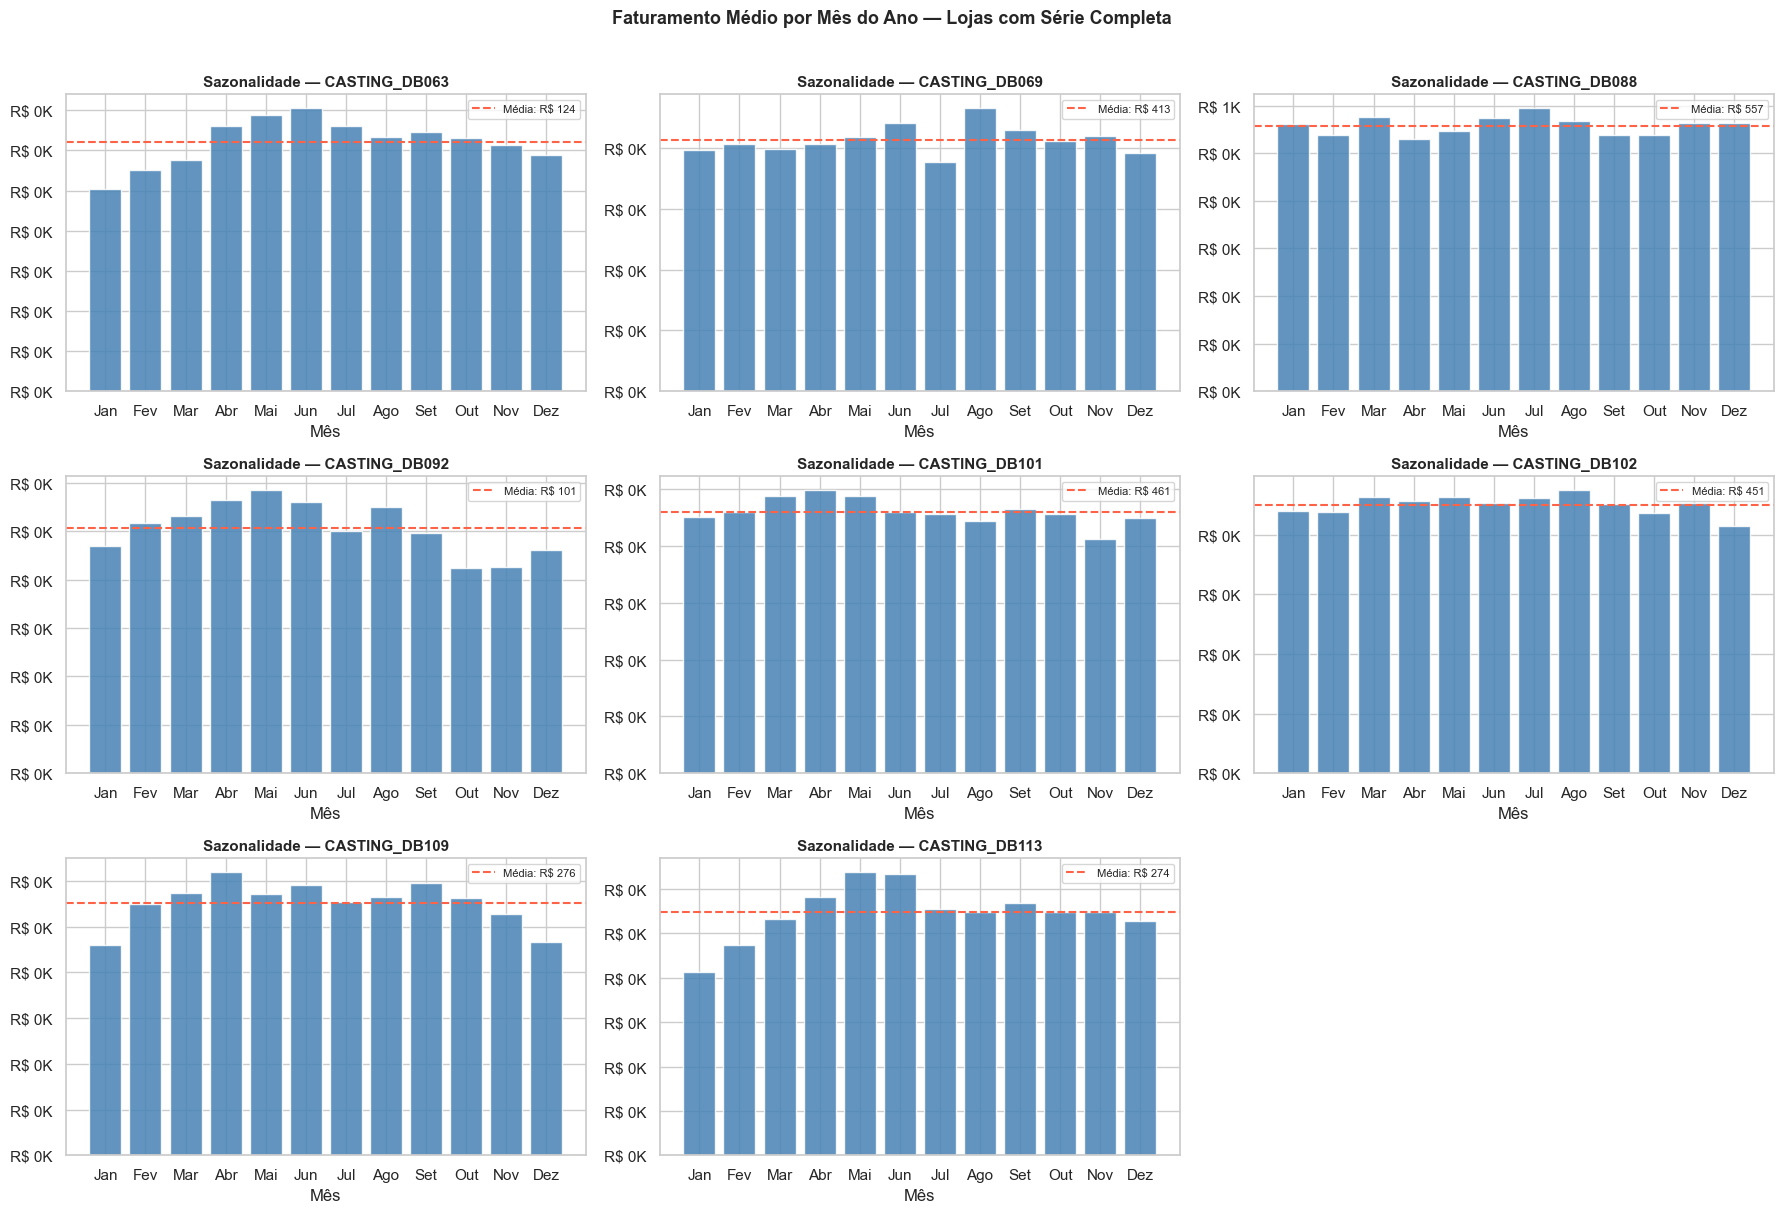

In [16]:
meses_nomes = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

n_lojas = len(lojas_completas)
n_cols  = min(n_lojas, 3)
n_rows  = (n_lojas + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for idx, loja in enumerate(sorted(lojas_completas)):
    df_loja = df_periodo[df_periodo['CLV_BANCO'] == loja]
    fat_mes = (
        df_loja.groupby(df_loja['VUF_DT'].dt.month)['VUF_VLRLIQFINAL']
        .mean().reset_index()
    )
    fat_mes.columns = ['Mes', 'Fat_Medio']
    fat_mes['Nome'] = fat_mes['Mes'].apply(lambda x: meses_nomes[x - 1])

    ax = axes_flat[idx]
    ax.bar(fat_mes['Nome'], fat_mes['Fat_Medio'], color='steelblue', alpha=0.85)
    media_g = fat_mes['Fat_Medio'].mean()
    ax.axhline(media_g, color='tomato', linestyle='--', linewidth=1.5,
               label=f'Média: R$ {media_g:,.0f}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e3:.0f}K'))
    ax.set_title(f'Sazonalidade — {loja}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mês')
    ax.legend(fontsize=8)

# Ocultar eixos extras
for idx in range(n_lojas, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Faturamento Médio por Mês do Ano — Lojas com Série Completa',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4.5 Distribuição do Ticket por Transação — Todas as Lojas

> **Correção aplicada:** a versão anterior criava apenas 2 subgráficos (`plt.subplots(1, 2)`), exibindo silenciosamente apenas as 2 primeiras lojas e ignorando as 6 restantes. Agora o painel é gerado dinamicamente para todas as 8 lojas.

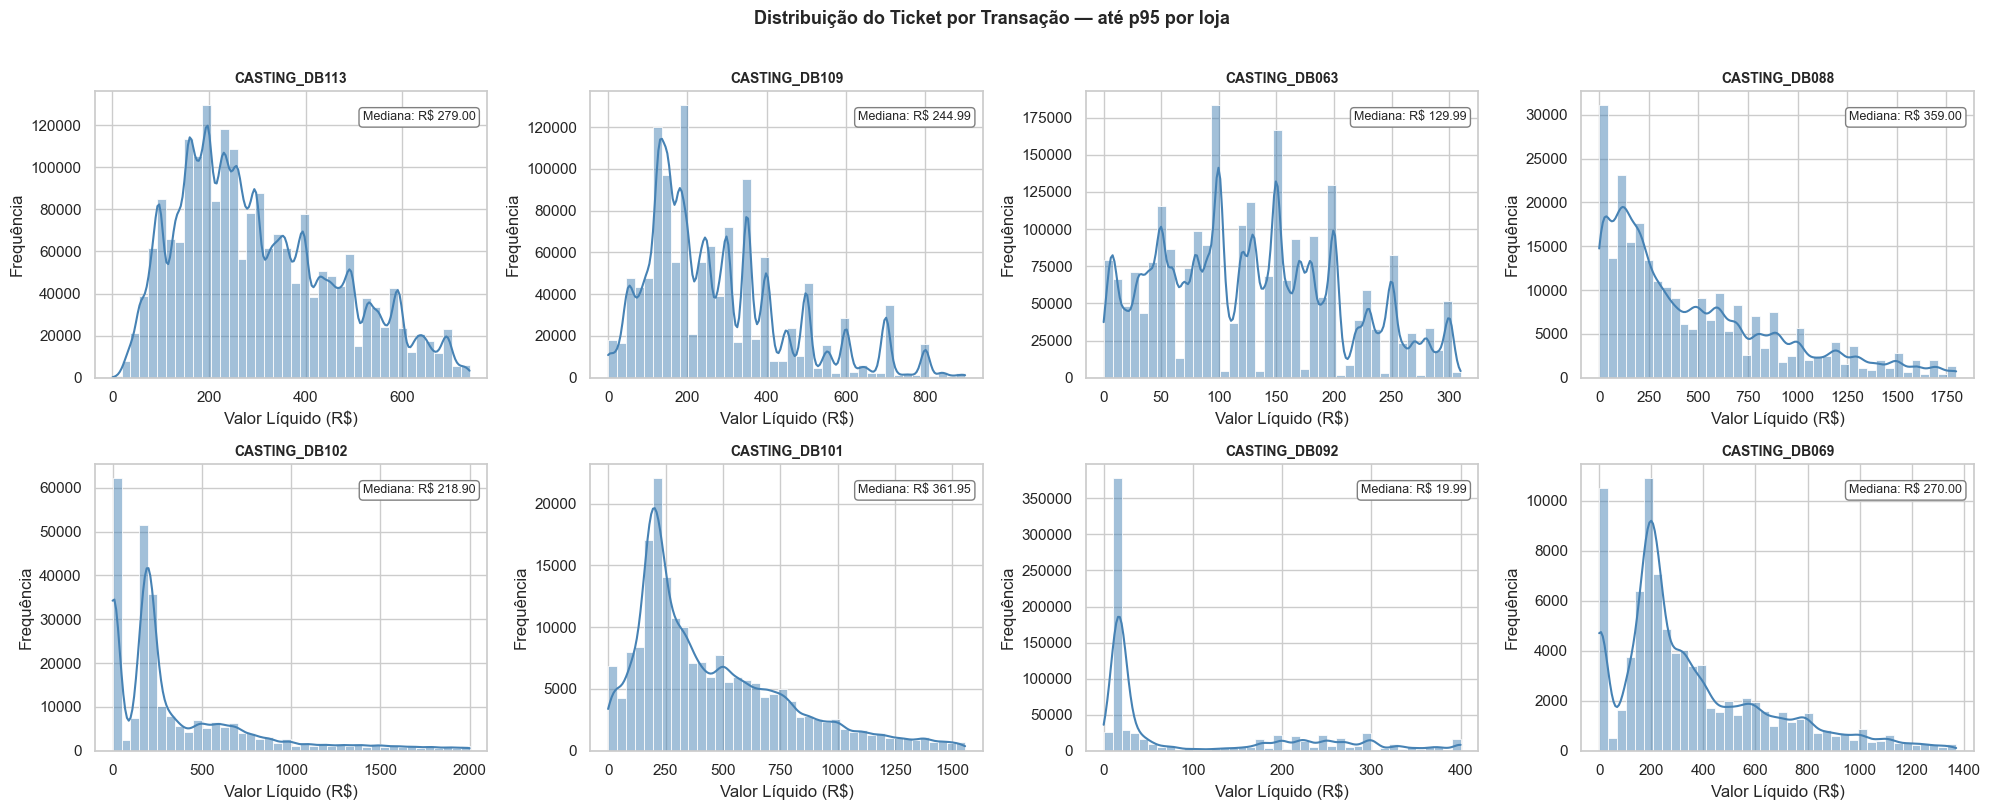

In [17]:
vendas_pos = df[df['VUF_VLRLIQFINAL'] > 0]
# Ordenar lojas por faturamento total (maior para menor)
lojas_ord = vendas_pos.groupby('CLV_BANCO')['VUF_VLRLIQFINAL'].sum().sort_values(ascending=False).index.tolist()

n_lojas = len(lojas_ord)
n_cols  = 4
n_rows  = (n_lojas + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for idx, loja in enumerate(lojas_ord):
    grp = vendas_pos[vendas_pos['CLV_BANCO'] == loja]['VUF_VLRLIQFINAL']
    p95 = grp.quantile(0.95)
    ax  = axes_flat[idx]
    sns.histplot(grp[grp <= p95], bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{loja}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor Líquido (R$)')
    ax.set_ylabel('Frequência')
    ax.text(0.97, 0.93, f'Mediana: R$ {grp.median():,.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

for idx in range(n_lojas, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Distribuição do Ticket por Transação — até p95 por loja',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4.6 Identificação de Outliers de Alto Valor por Loja

> **Correção aplicada:** a versão anterior buscava um outlier específico da loja `CASTING_DB106` (data e quantidade de produtos fixas), que não existe no dataset completo — retornando DataFrame vazio. Agora a análise é generalizada: identifica automaticamente os top outliers de cada loja com base no limiar p99.

In [18]:
# Limiar p99 por loja e top transações de maior valor
p99_por_loja = (
    df[df['VUF_VLRLIQFINAL'] > 0]
    .groupby('CLV_BANCO')['VUF_VLRLIQFINAL']
    .quantile(0.99)
    .rename('Limiar_p99')
)

fat_max_por_loja = df.groupby('CLV_BANCO')['VUF_VLRLIQFINAL'].max().rename('Fat_Max')

print('Limiar p99 e valor máximo por loja:')
display(pd.concat([p99_por_loja, fat_max_por_loja], axis=1))

print('\nTop 3 transações de maior valor por loja:')
top3 = (
    df[df['VUF_VLRLIQFINAL'] > 0]
    .sort_values('VUF_VLRLIQFINAL', ascending=False)
    .groupby('CLV_BANCO')
    .head(3)[['CLV_BANCO', 'VUF_DT', 'VUF_QTPRODUTO',
              'VUF_VLRBRUTOVENDA', 'VUF_VLRDESCONTO', 'VUF_VLRLIQFINAL']]
    .sort_values(['CLV_BANCO', 'VUF_VLRLIQFINAL'], ascending=[True, False])
)
display(top3)

Limiar p99 e valor máximo por loja:


,Limiar_p99,Fat_Max
CLV_BANCO,,
CASTING_DB063,449.99,"1,199.99"
CASTING_DB069,"2,569.99","9,159.24"
CASTING_DB088,"2,999.00","27,992.00"
CASTING_DB092,549.99,"2,519.88"
CASTING_DB101,"2,714.00","15,432.99"
CASTING_DB102,"4,003.02","15,125.00"
CASTING_DB109,"1,299.99","62,497.50"
CASTING_DB113,"1,260.00","72,800.00"



Top 3 transações de maior valor por loja:


,CLV_BANCO,VUF_DT,VUF_QTPRODUTO,VUF_VLRBRUTOVENDA,VUF_VLRDESCONTO,VUF_VLRLIQFINAL
1215356,CASTING_DB063,2023-02-08,1.00,"1,199.99",0.00,"1,199.99"
1218861,CASTING_DB063,2023-02-08,1.00,"1,199.99",0.00,"1,199.99"
1038869,CASTING_DB063,2022-12-24,1.00,"1,199.99",0.00,"1,199.99"
2887769,CASTING_DB069,2023-05-04,2.00,"11,813.00","2,653.76","9,159.24"
2887761,CASTING_DB069,2023-05-04,2.00,"11,813.00","2,653.76","9,159.24"
2906017,CASTING_DB069,2023-06-06,2.00,"12,275.00","3,437.00","8,838.00"
2967278,CASTING_DB088,2023-02-24,8.00,"27,992.00",0.00,"27,992.00"
2976277,CASTING_DB088,2023-08-24,5.00,"18,995.00",0.00,"18,995.00"
3216103,CASTING_DB088,2022-04-28,400.00,"17,400.00",0.00,"17,400.00"
3568669,CASTING_DB092,2022-09-28,14.00,"2,799.86",279.98,"2,519.88"


**Análise de outliers:** Cada loja possui seu próprio padrão de ticket. O limiar p99 calculado individualmente por loja é a referência correta para sinalizar vendas atípicas de atacado. Todas são mantidas no dataset com `FLAG_ATACADO = 1` para que o modelo possa identificar esse padrão.

---
# 5. Tratamento e Limpeza dos Dados

In [19]:
def tratamento_dados_transacionais(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline de limpeza e enriquecimento da base transacional.
    Retorna o dataset pronto para agregação e modelagem.

    Etapas:
      1. Cópia defensiva + correção de tipos
      2. Remoção de mês incompleto (out/2023)
      3. Remoção de erros reais de PDV (desconto > bruto em vendas positivas)
      4. Tratamento de nulos em PRO_CODIGO
      5. Remoção da coluna VUF_VLRTROCA (validada como sem dados úteis)
      6. Flags de negócio: devolução e outlier de atacado
      7. Variáveis temporais auxiliares
      8. Ordenação lógica
    """
    print(f'[IN]  Dimensão original    : {df.shape[0]:,} linhas × {df.shape[1]} colunas')
    dc = df.copy()

    # 1. Correção de tipos
    dc['VUF_DT'] = pd.to_datetime(dc['VUF_DT'], errors='coerce')

    # 2. Remove mês incompleto: outubro/2023 tem apenas 1 dia de dados
    n_out = (dc['VUF_DT'] >= '2023-10-01').sum()
    dc = dc[dc['VUF_DT'] < '2023-10-01']
    print(f'      Out/2023 removido    : {n_out:,} linhas (mês incompleto)')

    # 3. Remove erros reais de PDV
    mask_pdv = (dc['VUF_VLRDESCONTO'] > dc['VUF_VLRBRUTOVENDA']) & (dc['VUF_VLRBRUTOVENDA'] > 0)
    n_pdv = mask_pdv.sum()
    dc = dc[~mask_pdv]
    print(f'      Erros PDV removidos  : {n_pdv:,} linhas')

    # 4. PRO_CODIGO nulo: produto não mapeado, mas transação válida para o modelo
    n_pro = dc['PRO_CODIGO'].isnull().sum()
    dc['PRO_CODIGO'] = dc['PRO_CODIGO'].fillna('PRODUTO_NAO_MAPEADO')
    print(f'      PRO_CODIGO preenchido: {n_pro:,} registros')

    # 5. Remove VUF_VLRTROCA — verificar antes de descartar
    n_troca = (dc['VUF_VLRTROCA'] != 0).sum()
    if n_troca > 0:
        print(f'      ATENÇÃO: VUF_VLRTROCA tem {n_troca:,} valores não-zero — revisar antes de descartar!')
    else:
        print(f'      VUF_VLRTROCA removida : zerada em todo o período')
    dc.drop(columns=['VUF_VLRTROCA'], inplace=True)

    # 6a. Flag: devolução (bruto ou líquido negativo)
    dc['FLAG_DEVOLUCAO'] = np.where(dc['VUF_VLRLIQFINAL'] < 0, 1, 0)

    # 6b. Flag: venda de atacado — acima do p99 da própria loja
    p99_por_loja = (
        dc[dc['VUF_VLRLIQFINAL'] > 0]
        .groupby('CLV_BANCO')['VUF_VLRLIQFINAL']
        .quantile(0.99)
    )
    dc['FLAG_ATACADO'] = dc.apply(
        lambda r: 1 if r['VUF_VLRLIQFINAL'] > p99_por_loja.get(r['CLV_BANCO'], np.inf) else 0,
        axis=1
    )

    # 7. Variáveis temporais auxiliares
    dc['ANO']         = dc['VUF_DT'].dt.year
    dc['MES_NUM']     = dc['VUF_DT'].dt.month
    dc['PERIODO_MES'] = dc['VUF_DT'].dt.to_period('M')

    # 8. Ordenação lógica
    dc = dc.sort_values(by=['CLV_BANCO', 'VUF_DT']).reset_index(drop=True)

    print(f'[OUT] Dimensão após limpeza : {dc.shape[0]:,} linhas × {dc.shape[1]} colunas')
    print(f'      Devoluções sinalizadas: {dc["FLAG_DEVOLUCAO"].sum():,} ({dc["FLAG_DEVOLUCAO"].mean()*100:.1f}%)')
    print(f'      Vendas de atacado     : {dc["FLAG_ATACADO"].sum():,} ({dc["FLAG_ATACADO"].mean()*100:.2f}%)')
    return dc


df_tratado = tratamento_dados_transacionais(df)

[IN]  Dimensão original    : 8,297,456 linhas × 14 colunas
      Out/2023 removido    : 7,919 linhas (mês incompleto)
      Erros PDV removidos  : 4 linhas
      PRO_CODIGO preenchido: 3 registros
      VUF_VLRTROCA removida : zerada em todo o período
[OUT] Dimensão após limpeza : 8,289,533 linhas × 18 colunas
      Devoluções sinalizadas: 374,570 (4.5%)
      Vendas de atacado     : 68,031 (0.82%)


---
# 6. Agregação Mensal — Handoff para Modelagem

O modelo opera em **granularidade mensal**. Esta seção agrega os dados transacionais no nível que o modelo irá consumir.

In [20]:
def agregar_mensal(df_tratado: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega dados transacionais em granularidade mensal por loja.
    Gera a série temporal base para modelagem.
    """
    agg = df_tratado.groupby(['PERIODO_MES', 'CLV_BANCO']).agg(
        FAT_LIQUIDO_MES   = ('VUF_VLRLIQFINAL', 'sum'),
        FAT_BRUTO_MES     = ('VUF_VLRBRUTOVENDA', lambda x: x[x > 0].sum()),
        TOTAL_DESCONTOS   = ('VUF_VLRDESCONTO',   lambda x: x[x > 0].sum()),
        TOTAL_DEVOL_VALOR = ('VUF_VLRLIQFINAL',   lambda x: x[x < 0].sum()),
        QTD_TRANSACOES    = ('VUF_CODIGO',        'count'),
        QTD_DEVOL         = ('FLAG_DEVOLUCAO',    'sum'),
        QTD_ATACADO       = ('FLAG_ATACADO',      'sum'),
        TICKET_MEDIO      = ('VUF_VLRLIQFINAL',   lambda x: x[x > 0].mean()),
        TICKET_MEDIANO    = ('VUF_VLRLIQFINAL',   lambda x: x[x > 0].median()),
    ).reset_index()

    agg['TAXA_DESCONTO_PCT']  = (agg['TOTAL_DESCONTOS']         / agg['FAT_BRUTO_MES'] * 100).round(2)
    agg['TAXA_DEVOLUCAO_PCT'] = (agg['TOTAL_DEVOL_VALOR'].abs() / agg['FAT_BRUTO_MES'] * 100).round(2)

    agg = agg.sort_values(['CLV_BANCO', 'PERIODO_MES']).reset_index(drop=True)
    return agg


df_mensal = agregar_mensal(df_tratado)

print(f'Dataset mensal: {df_mensal.shape[0]} observações | '
      f'{df_mensal["CLV_BANCO"].nunique()} lojas | '
      f'{df_mensal["PERIODO_MES"].nunique()} períodos')
display(df_mensal.head(10))

Dataset mensal: 168 observações | 8 lojas | 21 períodos


,PERIODO_MES,CLV_BANCO,FAT_LIQUIDO_MES,FAT_BRUTO_MES,TOTAL_DESCONTOS,TOTAL_DEVOL_VALOR,QTD_TRANSACOES,QTD_DEVOL,QTD_ATACADO,TICKET_MEDIO,TICKET_MEDIANO,TAXA_DESCONTO_PCT,TAXA_DEVOLUCAO_PCT
0,2022-01,CASTING_DB063,"10,359,240.33","10,412,906.72","14,523.96","-39,142.43",111828,318,298,114.06,99.99,0.14,0.38
1,2022-02,CASTING_DB063,"10,980,198.36","11,033,972.01","19,952.95","-33,820.70",107689,285,409,116.06,99.99,0.18,0.31
2,2022-03,CASTING_DB063,"13,205,997.56","13,275,769.21","21,261.20","-48,510.45",122772,422,529,122.11,99.99,0.16,0.37
3,2022-04,CASTING_DB063,"16,111,945.79","16,206,681.09","29,943.10","-64,905.59",129551,424,885,140.17,129.99,0.18,0.40
4,2022-05,CASTING_DB063,"22,810,386.07","22,925,904.39","43,402.29","-72,116.05",170512,437,1447,152.78,149.99,0.19,0.31
5,2022-06,CASTING_DB063,"20,468,268.66","20,603,058.02","46,868.46","-87,923.90",150598,534,1553,156.27,149.99,0.23,0.43
6,2022-07,CASTING_DB063,"15,679,438.79","15,813,916.14","31,100.86","-103,376.49",124029,711,802,143.82,137.20,0.20,0.65
7,2022-08,CASTING_DB063,"16,309,237.28","16,398,593.59","39,160.01","-50,196.30",126824,356,840,147.15,139.99,0.24,0.31
8,2022-09,CASTING_DB063,"15,128,928.49","15,206,287.24","33,660.05","-43,698.70",114218,336,729,149.54,149.99,0.22,0.29
9,2022-10,CASTING_DB063,"17,460,713.27","17,540,602.15","32,262.04","-47,626.84",138177,360,709,143.08,129.99,0.18,0.27


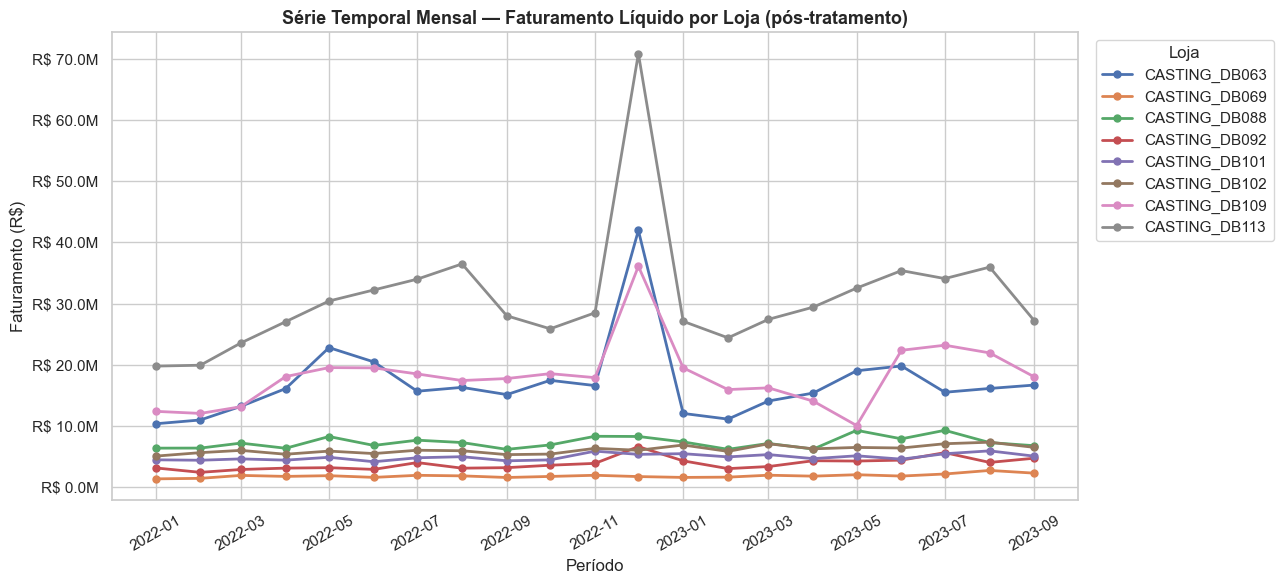

In [21]:
# Série temporal mensal final — todas as 8 lojas
fig, ax = plt.subplots(figsize=(13, 6))
for loja, grp in df_mensal.groupby('CLV_BANCO'):
    datas = grp['PERIODO_MES'].dt.to_timestamp()
    ax.plot(datas, grp['FAT_LIQUIDO_MES'], marker='o', markersize=5, linewidth=2, label=loja)

ax.yaxis.set_major_formatter(fmt_brl)
ax.set_title('Série Temporal Mensal — Faturamento Líquido por Loja (pós-tratamento)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Período')
ax.set_ylabel('Faturamento (R$)')
ax.legend(title='Loja', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
# 7. Resumo Final — Diagnóstico e Decisões

In [22]:
# Todos os valores do resumo são calculados dinamicamente — sem hardcode
n_pdv_resumo = int(((df['VUF_VLRDESCONTO'] > df['VUF_VLRBRUTOVENDA']) & (df['VUF_VLRBRUTOVENDA'] > 0)).sum())

print('=' * 65)
print('RESUMO DO PIPELINE DE EDA E TRATAMENTO')
print('=' * 65)
print(f"""
INGESTÃO
  Arquivos carregados    : {len(path_csv)} CSVs
  Linhas brutas          : {df.shape[0]:,}
  Colunas                : {df.shape[1]}

QUALIDADE DOS DADOS
  Duplicatas             : 0
  Nulos PRO_CODIGO       : preenchidos com 'PRODUTO_NAO_MAPEADO'
  Devoluções             : {df_tratado['FLAG_DEVOLUCAO'].sum():,} transações ({df_tratado['FLAG_DEVOLUCAO'].mean()*100:.1f}%)
  Erros de PDV removidos : {n_pdv_resumo:,}
  Inconsist. financeiras : {n_inconsist:,} linhas ({pct_inconsist:.1f}%) — impacto financeiro verificado e desprezível

DECISÕES DE TRATAMENTO
  Out/2023 removido      : mês incompleto (apenas 1 dia de dados)
  VUF_VLRTROCA           : coluna removida (zerada em todo o período)
  Erros PDV              : removidos (desconto > bruto em venda positiva)
  Devoluções             : mantidas com FLAG_DEVOLUCAO=1
  Outliers atacado       : mantidos com FLAG_ATACADO=1 (acima p99 da loja)

DATASET FINAL (transacional)
  Linhas                 : {df_tratado.shape[0]:,}
  Colunas                : {df_tratado.shape[1]}
  Período                : {str(df_tratado['PERIODO_MES'].min())} → {str(df_tratado['PERIODO_MES'].max())}

DATASET FINAL (mensal — pronto para modelagem)
  Linhas                 : {df_mensal.shape[0]}
  Lojas                  : {df_mensal['CLV_BANCO'].nunique()}
  Períodos               : {df_mensal['PERIODO_MES'].nunique()} meses
  Variável-alvo          : FAT_LIQUIDO_MES
""")
print('=' * 65)

RESUMO DO PIPELINE DE EDA E TRATAMENTO

INGESTÃO
  Arquivos carregados    : 8 CSVs
  Linhas brutas          : 8,297,456
  Colunas                : 14

QUALIDADE DOS DADOS
  Duplicatas             : 0
  Nulos PRO_CODIGO       : preenchidos com 'PRODUTO_NAO_MAPEADO'
  Devoluções             : 374,570 transações (4.5%)
  Erros de PDV removidos : 4
  Inconsist. financeiras : 984,417 linhas (11.9%) — impacto financeiro verificado e desprezível

DECISÕES DE TRATAMENTO
  Out/2023 removido      : mês incompleto (apenas 1 dia de dados)
  VUF_VLRTROCA           : coluna removida (zerada em todo o período)
  Erros PDV              : removidos (desconto > bruto em venda positiva)
  Devoluções             : mantidas com FLAG_DEVOLUCAO=1
  Outliers atacado       : mantidos com FLAG_ATACADO=1 (acima p99 da loja)

DATASET FINAL (transacional)
  Linhas                 : 8,289,533
  Colunas                : 18
  Período                : 2022-01 → 2023-09

DATASET FINAL (mensal — pronto para modelagem)
 

---
# 8. Exportação

In [32]:
import os


caminho_pasta = '../data/processed'
os.makedirs(caminho_pasta, exist_ok=True)


df_tratado.to_csv(f'{caminho_pasta}/df_tratado.csv', index=False)


df_mensal.to_csv(f'{caminho_pasta}/df_mensal.csv', index=False)

print("Arquivos salvos com sucesso!")

Arquivos salvos com sucesso!


In [ ]:
# df_tratado.to_parquet('../data/processed/df_transacional_tratado.parquet', index=False)
# print('Exportado: df_transacional_tratado.parquet')

# df_mensal.to_parquet('../data/processed/df_serie_temporal_mensal.parquet', index=False)
# print('Exportado: df_serie_temporal_mensal.parquet')